# Flat-Port Refraction and the Pinax Model for FishSense

FishSense images through a flat pane. A flat port is not a pinhole camera: rays
do not share a single viewpoint, so the in-air calibration is simply wrong
underwater, and the error depends on both field position and range.

This notebook asks three questions in simulation:

1. What does an **uncorrected** flat port cost FishSense laser ranging and fish
   length measurement?
2. How much of that does the **Pinax** model recover?
3. Where does Pinax actually beat the state of practice — an **in-water
   single-viewpoint (SVP) calibration**?

The third question is the one worth the effort. Question 1 has a large and
unsurprising answer; question 3 turns out to have a more nuanced one, and it is
what should decide whether FishSense adopts Pinax.

> Łuczyński, Pfingsthorn & Birk, *"The Pinax-model for accurate and efficient
> refraction correction of underwater cameras in flat-pane housings,"* Ocean
> Engineering 133 (2017) 9–22.

All geometry comes from `fishsense_wuwnet.refraction`, which is validated
against Table 1 of the paper in `tests/test_refraction.py`. Distances are in
metres, matching the FishSense laser-reconstruction convention.

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from tqdm.notebook import tqdm

from fishsense_wuwnet.refraction import (
    SALTY_WATER,
    SWEET_WATER,
    FlatPort,
    alpha_azimuth_to_pixel,
    fit_svp_model,
    focus_section,
    optimal_d0,
    project_water_points,
    reconstruct_points,
    water_radius,
)
from fishsense_wuwnet.pipelines import (
    back_project_pinax,
    back_project_svp,
    back_project_uncorrected,
    measure_length,
)

from fishsense_wuwnet import figstyle

figstyle.apply()  # print style for the paper's figures; see make_figures.py


## Setup of Simulation

The camera matches the system measured in the IMWUT work, so the numbers here are
directly comparable to `imwut_2026_fishsense_lite`.

In [2]:
IMAGE_WIDTH, IMAGE_HEIGHT = 4014, 3016
FOCAL_LENGTH_PX = 2850

IMAGE_WIDTH, IMAGE_HEIGHT, FOCAL_LENGTH_PX

(4014, 3016, 2850)

In [3]:
camera_intrinsics = np.array([
    [FOCAL_LENGTH_PX, 0, IMAGE_WIDTH / 2],
    [0, FOCAL_LENGTH_PX, IMAGE_HEIGHT / 2],
    [0, 0, 1]
])

camera_intrinsics

array([[2.850e+03, 0.000e+00, 2.007e+03],
       [0.000e+00, 2.850e+03, 1.508e+03],
       [0.000e+00, 0.000e+00, 1.000e+00]])

In [4]:
HALF_FOV = np.arctan(np.hypot(IMAGE_WIDTH / 2, IMAGE_HEIGHT / 2) / FOCAL_LENGTH_PX)

HALF_FOV, np.degrees(HALF_FOV)

(np.float64(0.7221294290958117), np.float64(41.37496854938164))

### The housing

`GLASS_THICKNESS_M` and `N_GLASS` are **placeholders** — replace them with the
measured FishSense housing. Section 3c shows how much they matter, which is the
argument for measuring rather than guessing them.

`d0` is the camera-to-glass distance. Following the paper we take the housing to
sit at its optimum `d0*`; Section 3c also tests what happens when it does not.
Note that `d0*` depends on the field of view, so it is computed from this
camera's actual FOV rather than the paper's 70° example.

In [5]:
GLASS_THICKNESS_M = 0.006     # 6 mm acrylic pane -- PLACEHOLDER
N_GLASS = 1.49                # acrylic
N_WATER = SALTY_WATER         # ocean deployment

GLASS_THICKNESS_M, N_GLASS, N_WATER

(0.006, 1.49, 1.342)

In [6]:
d0_star, virtual_cop, focus_length = optimal_d0(
    GLASS_THICKNESS_M, N_GLASS, N_WATER, HALF_FOV
)

d0_star * 1000, virtual_cop * 1000, focus_length * 1e6  # mm, mm, microns

(0.7291154165601155, 0.3518119228140262, 10.391436880450438)

The focus section is a few microns long: over this camera's field of view the
axial camera really does collapse to a virtual pinhole, sitting `virtual_cop`
down the optical axis. That is the assumption the whole Pinax model rests on,
and here it holds comfortably.

In [7]:
port = FlatPort(d0_star, GLASS_THICKNESS_M, N_GLASS, N_WATER)

port, port.d2

(FlatPort(d0=0.0007291154165601155, d1=0.006, n_glass=1.49, n_water=1.342, n_air=1.0),
 0.006729115416560115)

## What the flat port does to the image

A point at field angle `gamma` in the water is imaged as though it were at the
steeper angle `alpha`. The effect is nearly a fixed angular compression, which is
why it looks so much like ordinary radial distortion — and why an in-water
calibration can absorb most of it.

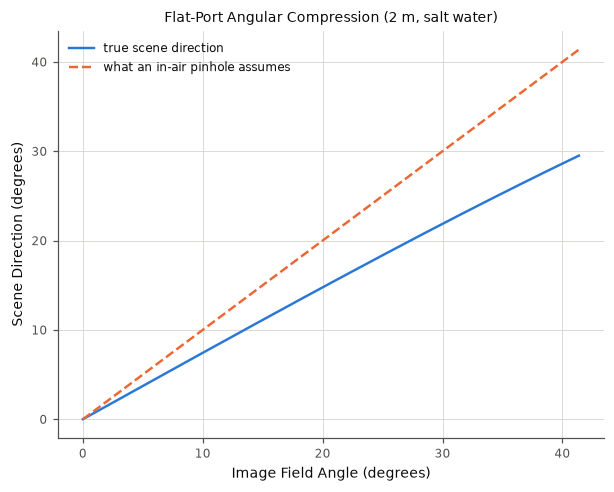

In [8]:
alpha_grid = np.linspace(0.0, HALF_FOV, 200)
apparent_radius = water_radius(alpha_grid, 2.0, port) / 2.0

fig, ax = plt.subplots()
ax.plot(np.degrees(alpha_grid), np.degrees(np.arctan(apparent_radius)), label="true scene direction")
ax.plot(np.degrees(alpha_grid), np.degrees(alpha_grid), linestyle="--", label="what an in-air pinhole assumes")
ax.set_title("Flat-Port Angular Compression (2 m, salt water)")
ax.set_xlabel("Image Field Angle (degrees)")
ax.set_ylabel("Scene Direction (degrees)")
ax.legend()

Text(0, 0.5, 'Radial Error (pixels)')

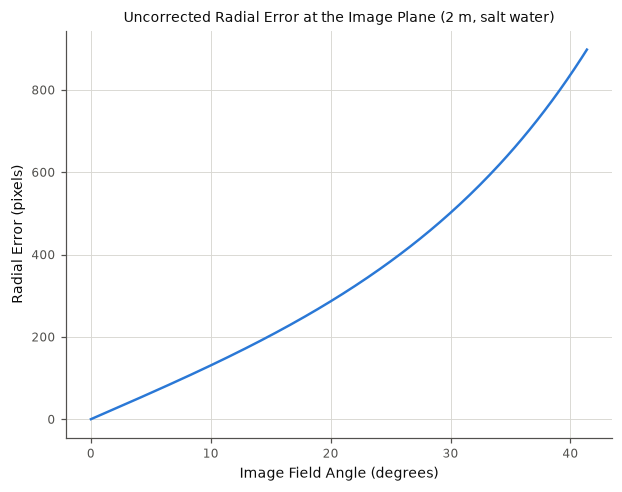

In [9]:
displacement_px = FOCAL_LENGTH_PX * (np.tan(alpha_grid) - apparent_radius)

fig, ax = plt.subplots()
ax.plot(np.degrees(alpha_grid), displacement_px)
ax.set_title("Uncorrected Radial Error at the Image Plane (2 m, salt water)")
ax.set_xlabel("Image Field Angle (degrees)")
ax.set_ylabel("Radial Error (pixels)")

## The three pipelines

**Uncorrected** — the in-air calibration used as-is. The "do nothing" case.

**In-water SVP** — the state of practice: take the rig into a pool, calibrate an
ordinary pinhole-plus-radial-distortion model on a target at one distance. This
is a *fair* baseline: fitting radial terms lets it absorb most of the angular
compression above. What it cannot absorb is the range dependence.

**Pinax** — back-project every pixel along its true refracted direction, from the
virtual centre of projection.

Only Pinax is told the housing geometry, and it is told the housing it *believes*
in — which is not necessarily the true one. Section 3 exploits that gap.

In [10]:
CALIBRATION_DEPTH_M = 2.0

svp_coeffs = fit_svp_model(port, HALF_FOV, CALIBRATION_DEPTH_M)

svp_coeffs, N_WATER  # leading coefficient should sit near the water index

(array([1.34312524, 0.5136825 , 0.47418758]), 1.342)

In [11]:
def uncorrected(pixels):
    return back_project_uncorrected(pixels, camera_intrinsics)


def svp(pixels):
    return back_project_svp(pixels, camera_intrinsics, svp_coeffs)


def pinax(pixels):
    return back_project_pinax(pixels, camera_intrinsics, port, virtual_cop)


PIPELINES = {"Uncorrected": uncorrected, "In-water SVP": svp, "Pinax": pinax}

list(PIPELINES)

['Uncorrected', 'In-water SVP', 'Pinax']

## How a dome compares — the state of practice

A flat pane is not the only option and is not the usual one. A **dome port** whose
centre of curvature coincides with the camera's entrance pupil bends nothing at all:
every camera ray leaves along a radius, meets both glass surfaces at normal incidence,
and an in-air calibration is valid underwater with no correction whatsoever. That is
not an approximation — it is exact, and `test_a_concentric_dome_is_optically_absent`
asserts it to machine precision.

So the honest question is not "how much does Pinax recover?" but **"why accept a
refractive port at all?"** Three answers, and only the third is optical. A dome large
enough for a wide lens is bulky, fragile and expensive; a dome's alignment is a
property of the lens's pupil position, which moves with zoom and focus and cannot be
inspected once the housing is closed; and a dome forms a *virtual image* a few
centimetres in front of the port, so the lens must focus far nearer than the subject.
None of that applies to a flat pane, and the camera we deploy is sold in one.

The comparison below is therefore between a flat port, which is wrong by a fixed
amount set by physics, and a dome, which is wrong by an amount set entirely by how
well it was assembled.

at the frame corner (41.4 deg off axis):
   flat port, uncorrected      -11.868 deg
   dome decentred    0 mm       +0.000 deg   (0.0000 of the flat port's)
   dome decentred    2 mm       +0.398 deg   (0.0336 of the flat port's)
   dome decentred    5 mm       +0.997 deg   (0.0840 of the flat port's)
   dome decentred   10 mm       +2.004 deg   (0.1689 of the flat port's)


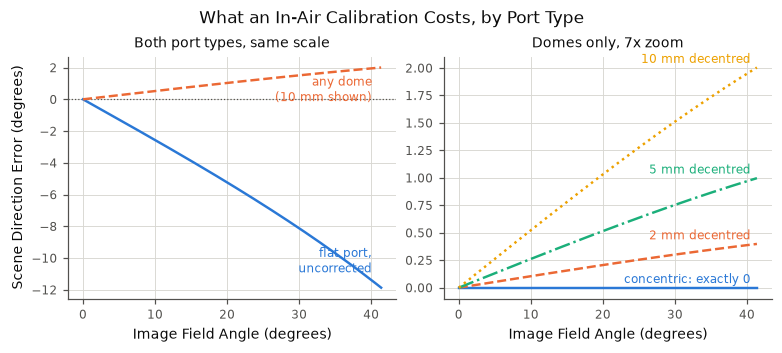

In [12]:
from fishsense_wuwnet.refraction import DomePort, dome_exit_ray, exit_ray

DOME_RADIUS = 0.050          # 100 mm dome, a common size for a compact housing
DOME_THICKNESS = GLASS_THICKNESS_M
DECENTRINGS_MM = (0.0, 2.0, 5.0, 10.0)

alpha_grid = np.linspace(0.0, HALF_FOV, 200)
degrees = np.degrees(alpha_grid)
_, gamma_flat = exit_ray(alpha_grid, port)
flat_error = np.degrees(gamma_flat - alpha_grid)

dome_error = {}
for mm in DECENTRINGS_MM:
    dome = DomePort(DOME_RADIUS, DOME_THICKNESS, N_GLASS, N_WATER, decentre=mm / 1000)
    _, gamma = dome_exit_ray(alpha_grid, dome)
    dome_error[mm] = np.degrees(gamma - alpha_grid)

# Two panels rather than two y-scales: the flat port's error is an order of
# magnitude larger than any dome's, so on one axis the dome curves collapse onto
# the zero line and cannot be compared with each other.
fig, axes = plt.subplots(1, 2, figsize=(7.0, 3.1), constrained_layout=True)

ax = axes[0]
ax.plot(degrees, flat_error, color=figstyle.SERIES[0])
ax.plot(degrees, dome_error[10.0], color=figstyle.SERIES[1], linestyle="--")
ax.axhline(0.0, color="#52514e", linewidth=0.8, linestyle=":", zorder=1)
ax.annotate("flat port,\nuncorrected", xy=(degrees[-1], flat_error[-1]),
            xytext=(-6, 10), textcoords="offset points", ha="right",
            color=figstyle.SERIES[0], fontsize=8)
ax.annotate("any dome\n(10 mm shown)", xy=(degrees[-1], dome_error[10.0][-1]), xytext=(-6, -22),
            textcoords="offset points", ha="right", color=figstyle.SERIES[1], fontsize=8)
ax.set_xlabel("Image Field Angle (degrees)")
ax.set_ylabel("Scene Direction Error (degrees)")
ax.set_title("Both port types, same scale", fontsize=9)
span_both = np.ptp(np.concatenate([flat_error, dome_error[10.0]]))

ax = axes[1]
for i, mm in enumerate(DECENTRINGS_MM):
    ax.plot(degrees, dome_error[mm], color=figstyle.SERIES[i % len(figstyle.SERIES)],
            linestyle=figstyle.DASHES[i % len(figstyle.DASHES)])
    label = "concentric: exactly 0" if mm == 0 else f"{mm:.0f} mm decentred"
    ax.annotate(label, xy=(degrees[-1], dome_error[mm][-1]), xytext=(-4, 3),
                textcoords="offset points", ha="right", fontsize=8,
                color=figstyle.SERIES[i % len(figstyle.SERIES)])
ax.set_xlabel("Image Field Angle (degrees)")
ax.set_title(f"Domes only, {span_both / np.ptp(dome_error[10.0]):.0f}x zoom", fontsize=9)

fig.suptitle("What an In-Air Calibration Costs, by Port Type")

print(f"at the frame corner ({np.degrees(HALF_FOV):.1f} deg off axis):")
print(f"   flat port, uncorrected      {flat_error[-1]:+7.3f} deg")
for mm in DECENTRINGS_MM:
    share = abs(dome_error[mm][-1] / flat_error[-1])
    print(f"   dome decentred {mm:4.0f} mm      {dome_error[mm][-1]:+7.3f} deg"
          f"   ({share:.4f} of the flat port's)")


The concentric dome is a flat line at zero, which is the point: it is not a better
correction, it is the absence of anything to correct. A dome misaligned by 5 mm — a
tenth of its own radius, a poor build — is still an order of magnitude better than the
flat pane it replaces.

What this does *not* say is that the flat port is a bad choice. It says the flat port
buys size, cost and robustness at a price that has to be paid in software, and the rest
of this notebook is about paying it. It also says something about which error is easier
to trust: the flat port's is a fixed function of the water index, identical on every
unit and every dive, while the dome's is an assembly tolerance that differs between
housings and changes whenever the lens is refocused.

## 1. Effect on laser ranging

The FishSense laser sits below and beside the lens and fires parallel to the
optical axis. Because it leaves the port at normal incidence it is not bent, only
displaced, so the in-water laser line is the physical one — no separate laser
refraction model is needed here.

Range comes from intersecting the camera ray through the laser dot with that line.

In [13]:
laser_position = np.array([-0.04, -0.11, 0])
laser_direction = np.array([0.0, 0.0, 1.0])

laser_position, laser_direction

(array([-0.04, -0.11,  0.  ]), array([0., 0., 1.]))

In [14]:
STEP_COUNT = 1000
t = np.linspace(0.5, 5.0, STEP_COUNT)   # FishSense images fish at roughly 0.5-5 m

p = laser_position[:, np.newaxis] + t[np.newaxis, :] * laser_direction[:, np.newaxis]

p.shape, p[:, 0], p[:, -1]

((3, 1000), array([-0.04, -0.11,  0.5 ]), array([-0.04, -0.11,  5.  ]))

In [15]:
alpha, azimuth = project_water_points(p.T, port)
laser_pixels = alpha_azimuth_to_pixel(alpha, azimuth, camera_intrinsics)

in_frame = (
    (laser_pixels[:, 0] >= 0) & (laser_pixels[:, 0] < IMAGE_WIDTH)
    & (laser_pixels[:, 1] >= 0) & (laser_pixels[:, 1] < IMAGE_HEIGHT)
)

np.all(in_frame), np.degrees(alpha[0]), np.degrees(alpha[-1])

(np.True_, np.float64(17.823696529404746), np.float64(1.7998984090379748))

In [16]:
def reconstruct(pixels, back_project):
    origin, directions = back_project(pixels)
    return reconstruct_points(directions, origin, laser_position, laser_direction)


z_errors = {}
for name, back_project in PIPELINES.items():
    reconstructed, _ = reconstruct(laser_pixels, back_project)
    z_errors[name] = np.abs(reconstructed[:, 2] - p[2, :]) / p[2, :] * 100

{name: (float(e.min()), float(e.max())) for name, e in z_errors.items()}

{'Uncorrected': (25.50587477845848, 27.191726913562132),
 'In-water SVP': (0.00017502308943857195, 0.07588833391332983),
 'Pinax': (4.855078814343202e-06, 0.00036554985509213117)}

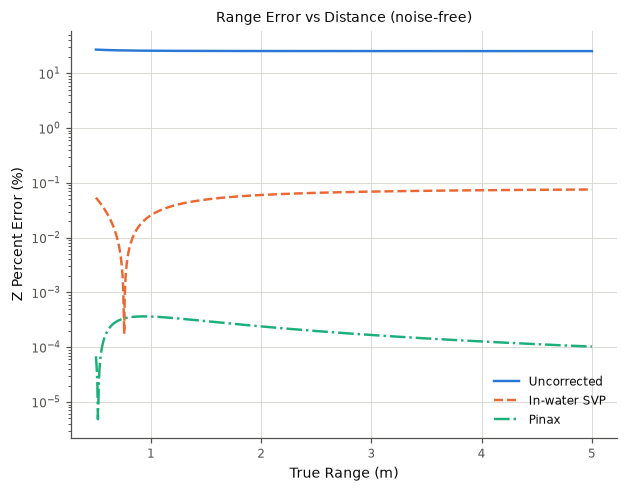

In [17]:
fig, ax = plt.subplots()

for name, error in z_errors.items():
    ax.plot(t, error, label=name, **figstyle.pipeline(name))

ax.set_yscale("log")
ax.set_title("Range Error vs Distance (noise-free)")
ax.set_xlabel("True Range (m)")
ax.set_ylabel("Z Percent Error (%)")
ax.legend()

An uncorrected flat port costs about **25% in range** — the in-air focal length is
wrong by roughly the water refraction index, and it shows up almost entirely as a
scale error. Both corrections remove essentially all of it.

### With pixel noise

Reusing the noise levels from the IMWUT reconstruction study, where `(3, 5)` is
the real-world estimate for detected laser-dot centroids.

In [18]:
np.random.seed(0)

stds = [(0.0, 0.0), (0.5, 0.5), (1.0, 1.0), (2.0, 2.0), (3.0, 5.0), (5.0, 5.0), (8.0, 8.0)]

z_errors_by_stds = {name: [] for name in PIPELINES}
for x_std, y_std in stds:
    noisy = laser_pixels.copy()
    noisy[:, 0] += np.random.normal(0, x_std, laser_pixels.shape[0])
    noisy[:, 1] += np.random.normal(0, y_std, laser_pixels.shape[0])

    for name, back_project in PIPELINES.items():
        reconstructed, _ = reconstruct(noisy, back_project)
        z_errors_by_stds[name].append(np.abs(reconstructed[:, 2] - p[2, :]) / p[2, :] * 100)

{name: len(v) for name, v in z_errors_by_stds.items()}

{'Uncorrected': 7, 'In-water SVP': 7, 'Pinax': 7}

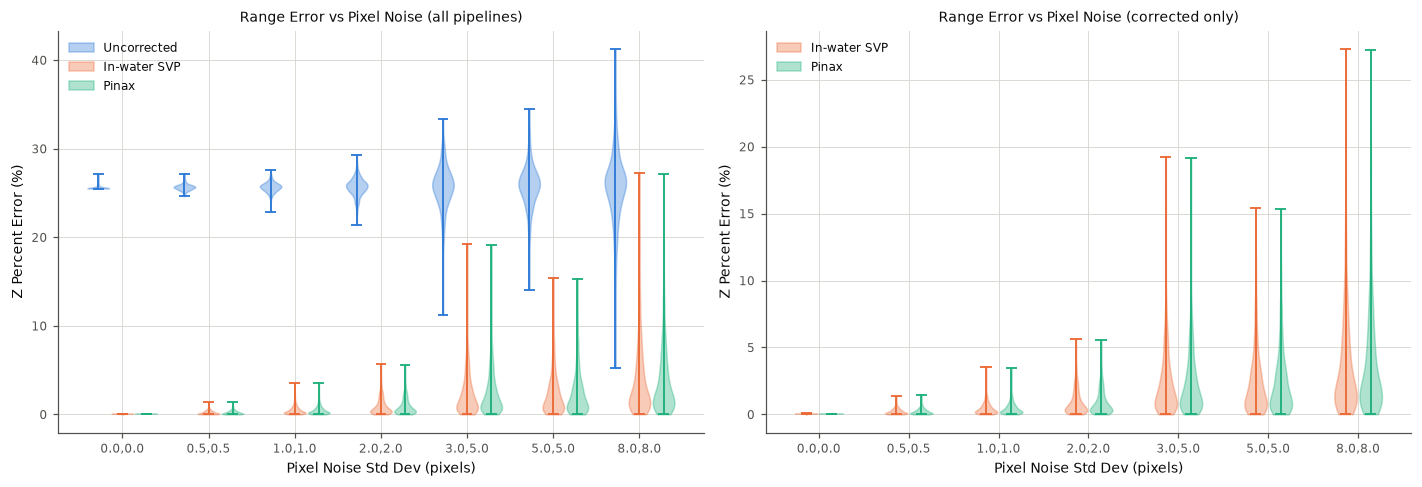

In [19]:
fig, axes = plt.subplots(1, 2, figsize=(13, 4.5))

for ax, names in zip(axes, (list(PIPELINES), ["In-water SVP", "Pinax"])):
    for offset, name in enumerate(names):
        positions = np.arange(len(stds)) + 0.28 * (offset - (len(names) - 1) / 2)
        parts = ax.violinplot(z_errors_by_stds[name], positions=positions, widths=0.25)
        figstyle.colour_violin(parts, figstyle.PIPELINE_STYLE[name]["color"])
        parts["bodies"][0].set_label(name)
    ax.set_xticks(np.arange(len(stds)))
    ax.set_xticklabels([f"{x},{y}" for x, y in stds])
    ax.set_xlabel("Pixel Noise Std Dev (pixels)")
    ax.set_ylabel("Z Percent Error (%)")
    ax.legend()

axes[0].set_title("Range Error vs Pixel Noise (all pipelines)")
axes[1].set_title("Range Error vs Pixel Noise (corrected only)")
fig.tight_layout()

Once either correction is applied, range error is dominated by pixel noise rather
than by refraction. The uncorrected bias is so large that noise is invisible
beside it.

## 2. Effect on fish length measurement

Range is the *easy* case: the laser dot sits close to the optical axis, where the
distortion is smallest. Length measurement is not — the head and tail are spread
across the frame, exactly where a flat port bends things most.

Here a fish of known length is placed at a fixed range and swept from the centre
of the frame outward. Each pipeline estimates the range from its own laser dot
and then measures the length, so range and geometry errors compound as they would
in the field.

In [20]:
FISH_LENGTH_M = 0.30
MEASUREMENT_DEPTH_M = 2.0

frame_half_width = water_radius(np.arctan((IMAGE_WIDTH / 2) / FOCAL_LENGTH_PX),
                                MEASUREMENT_DEPTH_M, port)

FISH_LENGTH_M, MEASUREMENT_DEPTH_M, frame_half_width

(0.3, 2.0, np.float64(0.9497831068840351))

In [21]:
def image_points(points):
    a, az = project_water_points(points, port)
    return alpha_azimuth_to_pixel(a, az, camera_intrinsics)


centre_offsets = np.linspace(0.0, 0.75 * frame_half_width, 60)
zeros = np.zeros_like(centre_offsets)
depths = np.full_like(centre_offsets, MEASUREMENT_DEPTH_M)

head_pixels = image_points(np.stack([centre_offsets + FISH_LENGTH_M / 2, zeros, depths], -1))
tail_pixels = image_points(np.stack([centre_offsets - FISH_LENGTH_M / 2, zeros, depths], -1))

head_pixels.shape, tail_pixels.shape

((60, 2), (60, 2))

In [22]:
laser_pixel_at_depth = image_points(laser_position + MEASUREMENT_DEPTH_M * laser_direction)

length_errors = {}
for name, back_project in PIPELINES.items():
    reconstructed, _ = reconstruct(laser_pixel_at_depth, back_project)
    measured = measure_length(head_pixels, tail_pixels, reconstructed[2], back_project)
    length_errors[name] = (measured - FISH_LENGTH_M) / FISH_LENGTH_M * 100

{name: float(e[-1]) for name, e in length_errors.items()}

{'Uncorrected': 17.746375750380093,
 'In-water SVP': 0.030487508336692525,
 'Pinax': 0.0007657971205499159}

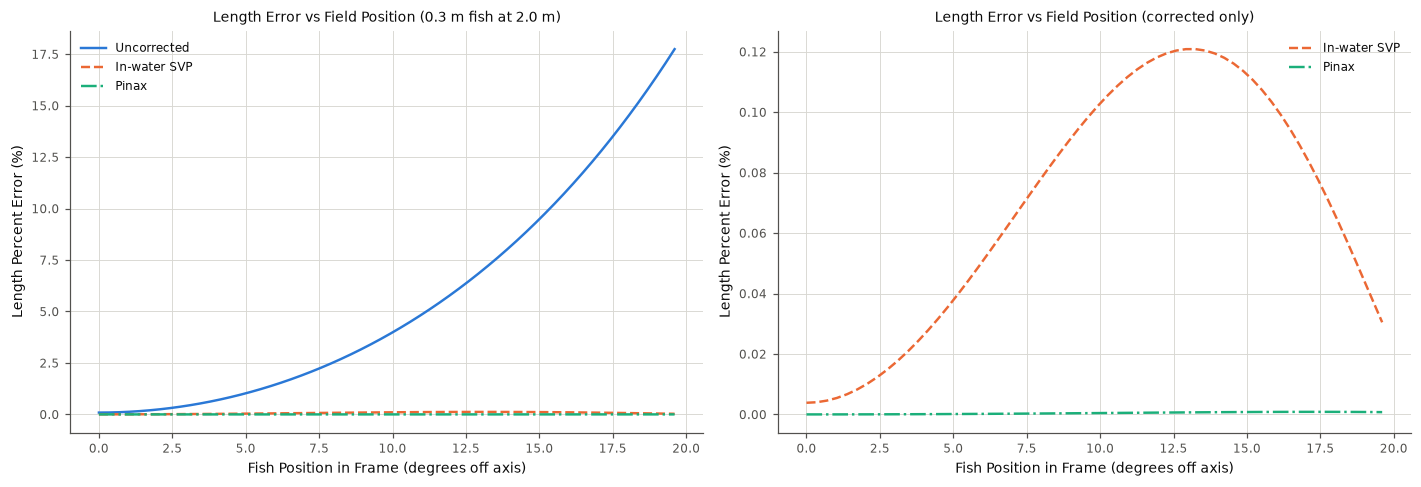

In [23]:
fig, axes = plt.subplots(1, 2, figsize=(13, 4.5))

field_angle_deg = np.degrees(np.arctan(centre_offsets / MEASUREMENT_DEPTH_M))

for ax, names in zip(axes, (list(PIPELINES), ["In-water SVP", "Pinax"])):
    for name in names:
        ax.plot(field_angle_deg, length_errors[name], label=name, **figstyle.pipeline(name))
    ax.set_xlabel("Fish Position in Frame (degrees off axis)")
    ax.set_ylabel("Length Percent Error (%)")
    ax.legend()

axes[0].set_title(f"Length Error vs Field Position ({FISH_LENGTH_M} m fish at {MEASUREMENT_DEPTH_M} m)")
axes[1].set_title("Length Error vs Field Position (corrected only)")
fig.tight_layout()

This is the headline. An uncorrected flat port measures a fish near the frame
edge **~18% too long**, and the error grows steeply with field position — so the
same fish gives a different length depending on where the diver framed it. That
is a bias no amount of averaging removes.

Both corrections reduce it to well under a percent. Note that on geometry alone,
the in-water SVP calibration is nearly as good as Pinax. That is a real result,
not a modelling artifact, and it is why the next section matters.

## 3. Where SVP and Pinax actually differ

If a properly fitted in-water calibration is geometrically almost as good, why
adopt Pinax? Three places where they come apart. The simulation ranks them
differently from intuition, so the ordering here is the one the numbers support,
not the one the literature emphasises.

### 3a. Housing geometry

A flat port hard against the lens is *almost* a pure angular map, and radial
distortion fits an angular map exactly at every range. What an SVP model cannot
absorb is the sideways offset a ray accumulates crossing the port,
`d0·tan(alpha) + d1·tan(beta)`, whose relative size grows as `1/Z`.

So the SVP model degrades with the thickness of the pane and the air gap behind
it — and it is only ever exact at its calibration distance.

In [24]:
geometry_cases = [
    ("d0 = 0.5 mm, d1 = 1 mm (tight, thin)", 0.0005, 0.001),
    ("d0 = d0*, d1 = 6 mm (this housing)", d0_star, GLASS_THICKNESS_M),
    ("d0 = 5 mm, d1 = 6 mm", 0.005, GLASS_THICKNESS_M),
    ("d0 = 25 mm, d1 = 10 mm (loose)", 0.025, 0.010),
]

ranges = np.linspace(0.4, 5.0, 40)
geometry_errors = {}

for label, d0, d1 in tqdm(geometry_cases):
    case_port = FlatPort(d0, d1, N_GLASS, N_WATER)
    case_coeffs = fit_svp_model(case_port, HALF_FOV, CALIBRATION_DEPTH_M)

    errors = []
    for depth in ranges:
        offset = 0.5 * water_radius(np.arctan((IMAGE_WIDTH / 2) / FOCAL_LENGTH_PX), depth, case_port)
        head = np.array([offset + FISH_LENGTH_M / 2, 0.0, depth])
        tail = np.array([offset - FISH_LENGTH_M / 2, 0.0, depth])

        a, az = project_water_points(np.stack([head, tail]), case_port)
        px = alpha_azimuth_to_pixel(a, az, camera_intrinsics)

        measured = measure_length(
            px[0], px[1], depth,
            lambda q: back_project_svp(q, camera_intrinsics, case_coeffs),
        )
        errors.append(abs(measured - FISH_LENGTH_M) / FISH_LENGTH_M * 100)

    geometry_errors[label] = np.array(errors)

{k: float(v.max()) for k, v in geometry_errors.items()}

  0%|          | 0/4 [00:00<?, ?it/s]

{'d0 = 0.5 mm, d1 = 1 mm (tight, thin)': 0.07506349506682572,
 'd0 = d0*, d1 = 6 mm (this housing)': 0.14741972079881002,
 'd0 = 5 mm, d1 = 6 mm': 0.33270427158371696,
 'd0 = 25 mm, d1 = 10 mm (loose)': 2.3675049169197457}

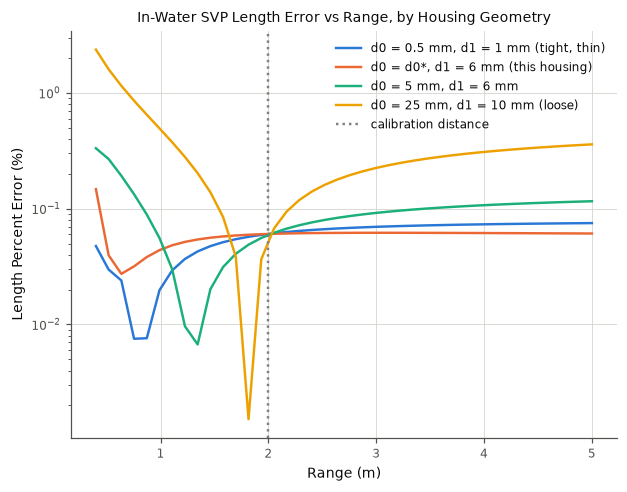

In [25]:
fig, ax = plt.subplots()

for label, errors in geometry_errors.items():
    ax.plot(ranges, errors, label=label)

ax.axvline(CALIBRATION_DEPTH_M, color="grey", linestyle=":", label="calibration distance")
ax.set_yscale("log")
ax.set_title("In-Water SVP Length Error vs Range, by Housing Geometry")
ax.set_xlabel("Range (m)")
ax.set_ylabel("Length Percent Error (%)")
ax.legend(fontsize=8)

Each curve dips at the calibration distance and rises away from it — the
signature of a single-viewpoint model applied to an axial camera. A tight, thin
port stays under a tenth of a percent; a loose one does not. Pinax has no such
dip because it does not assume a single viewpoint in the first place.

**This is why the housing geometry needs to be measured, not guessed.**

### 3b. A change in salinity

An in-water calibration is only valid for the water it was performed in. Calibrate
in a fresh-water pool, dive in the sea, and the calibration is wrong — and the only
fix is another pool session.

Pinax takes the water refraction index as a parameter, so adapting is free. But it
is not magic: it needs the index to be roughly right, which is the case for
deriving it from CTD salinity rather than assuming.

In [26]:
water_indices = np.linspace(1.330, 1.348, 40)

pool_coeffs = fit_svp_model(
    FlatPort(d0_star, GLASS_THICKNESS_M, N_GLASS, SWEET_WATER), HALF_FOV, CALIBRATION_DEPTH_M
)

salinity_errors = {"In-water SVP (calibrated in fresh water)": [], "Pinax (assuming fresh water)": []}

for n_true in tqdm(water_indices):
    true_port = FlatPort(d0_star, GLASS_THICKNESS_M, N_GLASS, n_true)
    offset = 0.5 * water_radius(np.arctan((IMAGE_WIDTH / 2) / FOCAL_LENGTH_PX),
                                MEASUREMENT_DEPTH_M, true_port)

    head = np.array([offset + FISH_LENGTH_M / 2, 0.0, MEASUREMENT_DEPTH_M])
    tail = np.array([offset - FISH_LENGTH_M / 2, 0.0, MEASUREMENT_DEPTH_M])
    a, az = project_water_points(np.stack([head, tail]), true_port)
    px = alpha_azimuth_to_pixel(a, az, camera_intrinsics)

    sweet_port = FlatPort(d0_star, GLASS_THICKNESS_M, N_GLASS, SWEET_WATER)
    _, sweet_cop, _ = optimal_d0(GLASS_THICKNESS_M, N_GLASS, SWEET_WATER, HALF_FOV)

    for label, back_project in (
        ("In-water SVP (calibrated in fresh water)",
         lambda q: back_project_svp(q, camera_intrinsics, pool_coeffs)),
        ("Pinax (assuming fresh water)",
         lambda q: back_project_pinax(q, camera_intrinsics, sweet_port, sweet_cop)),
    ):
        measured = measure_length(px[0], px[1], MEASUREMENT_DEPTH_M, back_project)
        salinity_errors[label].append(abs(measured - FISH_LENGTH_M) / FISH_LENGTH_M * 100)

salinity_errors = {k: np.array(v) for k, v in salinity_errors.items()}
at_sea = {k: float(np.interp(SALTY_WATER, water_indices, v)) for k, v in salinity_errors.items()}

at_sea, {k: float(v.max()) for k, v in salinity_errors.items()}

  0%|          | 0/40 [00:00<?, ?it/s]

({'In-water SVP (calibrated in fresh water)': 0.8503482233237677,
  'Pinax (assuming fresh water)': 0.7939346688990064},
 {'In-water SVP (calibrated in fresh water)': 1.3778918207460837,
  'Pinax (assuming fresh water)': 1.3213055187675609})

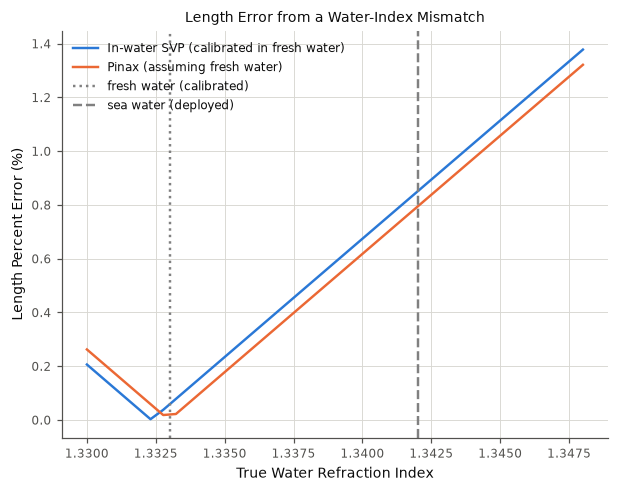

In [27]:
fig, ax = plt.subplots()

for label, errors in salinity_errors.items():
    ax.plot(water_indices, errors, label=label)

ax.axvline(SWEET_WATER, color="grey", linestyle=":", label="fresh water (calibrated)")
ax.axvline(SALTY_WATER, color="grey", linestyle="--", label="sea water (deployed)")
ax.set_title("Length Error from a Water-Index Mismatch")
ax.set_xlabel("True Water Refraction Index")
ax.set_ylabel("Length Percent Error (%)")
ax.legend(fontsize=8)

Both methods degrade at the same rate when the assumed water index is wrong — the
error is in the physics, not in the correction method. The difference is what it
costs to fix: Pinax recomputes from a CTD reading, while the SVP model needs
another calibration session in water of the right salinity.

Calibrating in fresh water and diving in the sea costs about **0.8% of length**
for either method — small next to the 18% of doing nothing, but larger than every
other residual in this notebook. Deriving the index from CTD salinity is worth
doing, and it is the one correction only Pinax can apply without another dive.

### 3c. Calibration noise

This is the argument the paper itself makes for its field results. Underwater
visibility is worse than in air even in a clean pool, so corner detection is
blurrier and the calibration that comes out is noisier.

It is worth stating up front that this simulation does **not** reproduce that as a
large effect — see the discussion below the plot.

Pinax calibrates **in air**, on a sharp target, once. The SVP model must be fitted
from in-water observations. Below, both are fitted from the same number of points
and differ only in the pixel noise on those observations.

In [28]:
N_CALIBRATION_POINTS = 400
IN_AIR_PIXEL_STD = 0.3      # sharp target, dry
IN_WATER_PIXEL_STD = 1.5    # blur, backscatter, awkward rig handling
N_TRIALS = 300

N_CALIBRATION_POINTS, IN_AIR_PIXEL_STD, IN_WATER_PIXEL_STD, N_TRIALS

(400, 0.3, 1.5, 300)

In [29]:
def calibrate_svp_noisy(rng, pixel_std):
    """Fit the in-water SVP model from noisy detected corners."""
    a = rng.uniform(0.02, HALF_FOV, N_CALIBRATION_POINTS)
    u = water_radius(a, CALIBRATION_DEPTH_M, port) / CALIBRATION_DEPTH_M
    y = np.tan(a) + rng.normal(0, pixel_std / FOCAL_LENGTH_PX, N_CALIBRATION_POINTS)
    basis = np.stack([u ** (2 * i + 1) for i in range(len(svp_coeffs))], axis=-1)
    return np.linalg.lstsq(basis, y, rcond=None)[0]


def calibrate_focal_noisy(rng, pixel_std):
    """Fit the in-air focal length from noisy detected corners (no refraction in air)."""
    a = rng.uniform(0.02, HALF_FOV, N_CALIBRATION_POINTS)
    y = np.tan(a)
    observed = FOCAL_LENGTH_PX * y + rng.normal(0, pixel_std, N_CALIBRATION_POINTS)
    return float(np.sum(observed * y) / np.sum(y * y))

In [30]:
rng = np.random.default_rng(0)

offset = 0.5 * frame_half_width
head = np.array([offset + FISH_LENGTH_M / 2, 0.0, MEASUREMENT_DEPTH_M])
tail = np.array([offset - FISH_LENGTH_M / 2, 0.0, MEASUREMENT_DEPTH_M])
a, az = project_water_points(np.stack([head, tail]), port)
fish_pixels = alpha_azimuth_to_pixel(a, az, camera_intrinsics)

calibration_errors = {"In-water SVP": [], "Pinax": []}

for _ in tqdm(range(N_TRIALS)):
    noisy_coeffs = calibrate_svp_noisy(rng, IN_WATER_PIXEL_STD)
    measured = measure_length(fish_pixels[0], fish_pixels[1], MEASUREMENT_DEPTH_M,
                              lambda q: back_project_svp(q, camera_intrinsics, noisy_coeffs))
    calibration_errors["In-water SVP"].append((measured - FISH_LENGTH_M) / FISH_LENGTH_M * 100)

    noisy_focal = calibrate_focal_noisy(rng, IN_AIR_PIXEL_STD)
    noisy_K = camera_intrinsics.copy()
    noisy_K[0, 0] = noisy_K[1, 1] = noisy_focal
    measured = measure_length(fish_pixels[0], fish_pixels[1], MEASUREMENT_DEPTH_M,
                              lambda q: back_project_pinax(q, noisy_K, port, virtual_cop))
    calibration_errors["Pinax"].append((measured - FISH_LENGTH_M) / FISH_LENGTH_M * 100)

{k: (float(np.mean(v)), float(np.std(v))) for k, v in calibration_errors.items()}

  0%|          | 0/300 [00:00<?, ?it/s]

{'In-water SVP': (0.057181726838022084, 0.018781714585994324),
 'Pinax': (0.00046398038476151243, 0.0009180256039506104)}

Text(0, 0.5, 'Length Percent Error (%)')

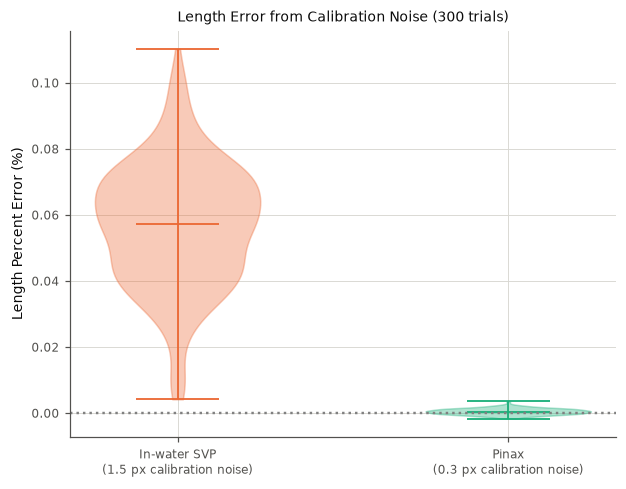

In [31]:
fig, ax = plt.subplots()

for position, name in enumerate(("In-water SVP", "Pinax")):
    figstyle.colour_violin(
        ax.violinplot([calibration_errors[name]], positions=[position], showmeans=True),
        figstyle.PIPELINE_STYLE[name]["color"],
    )
ax.set_xticks([0, 1])
ax.set_xticklabels([f"In-water SVP\n({IN_WATER_PIXEL_STD} px calibration noise)",
                    f"Pinax\n({IN_AIR_PIXEL_STD} px calibration noise)"])
ax.axhline(0.0, color="grey", linestyle=":")
ax.set_title(f"Length Error from Calibration Noise ({N_TRIALS} trials)")
ax.set_ylabel("Length Percent Error (%)")

The spread is about **20x tighter** for Pinax, which is far more than the 5x
ratio of the input noise. The extra amplification is not about the water: the SVP
model has to estimate three coefficients from a nearly collinear basis
(`u`, `u^3`, `u^5`), so it converts calibration noise into length error much more
efficiently than a single-focal-length fit does.

But note the **absolute** magnitudes: 0.06% versus 0.0005%. At 400 calibration
points and 1.5 px of noise, calibrating in water costs well under a tenth of a
percent — the smallest of the three effects in this section, not the largest.

That is a genuine disagreement with the paper's explanation of its field results,
and the honest reading is that Gaussian jitter on detected corners is the wrong
model for what actually goes wrong with an in-water calibration. Real pool
sessions lose whole views to blur and glare, give poorer pose diversity, and
produce outliers rather than clean noise. Reproducing the paper's effect would
need that failure mode modelled, not a larger sigma.

## Summary

For the FishSense Lite camera through a 6 mm acrylic pane at its optimal spacing:

| | Range error | Length error at frame edge |
|---|---|---|
| Uncorrected (in-air calibration) | ~25% | ~18% |
| In-water SVP calibration | <0.1% | <0.2% |
| Pinax | ~0% | ~0% |

**Correcting for refraction at all is not optional.** An uncorrected flat port
biases fish length by up to ~18% depending only on where in the frame the fish
happened to be — a systematic error larger than anything else in the FishSense
budget, and one that averaging cannot remove.

**Choosing Pinax over an in-water calibration is a more subtle call.** On geometry
alone, with a tight housing, a properly fitted in-water SVP model is nearly as
good. Ranking the residuals by what this notebook actually measured:

| Effect | Cost in length | Only Pinax fixes it? |
|---|---|---|
| Wrong water index (fresh calibration, sea dive) | ~0.8% | Both suffer; only Pinax retunes without a dive |
| Loose or thick housing (d0 = 25 mm, d1 = 10 mm) | up to ~2.4% | Yes — SVP error grows away from calibration range |
| This housing, in-water SVP, correct water | ~0.15% | Marginal |
| In-water calibration noise (1.5 px, 400 points) | ~0.06% | Marginal |

So the real case for Pinax is **salinity adaptability** and **tolerance of housing
geometry** — not, as we expected going in, calibration noise. If FishSense keeps a
tight housing, always calibrates in water of the deployment salinity, and can
afford the pool time, an in-water SVP calibration is defensible on these numbers.
Pinax wins when any of those three conditions fails, which in practice they
usually do.

### What this needs before it is a claim about the real system

- The true `GLASS_THICKNESS_M`, `N_GLASS`, and measured `d0` for the FishSense
  housing. Section 3a shows this changes the conclusion, and `d0` is currently
  assumed optimal rather than measured.
- Lens distortion is assumed removed by the in-air calibration and cancels between
  pipelines. A real wide-angle lens will not undistort perfectly at the frame edge,
  which is exactly where the length error is largest.
- The laser is treated as unrefracted, which holds only while it fires parallel to
  the optical axis. A verged laser would need its own refraction model.